# Linear Regression

In [46]:
import sys 
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
%reload_ext autoreload
%autoreload 2
# misc imports
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd

# sklearn imports
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

# PyTorch imports
import torch
import torch.nn as nn

# own imports
from models.linear_regression import LinearRegression
from metrics.regression import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)
from utils.timings import (
    benchmark_model,
    benchmark_pytorch_model
)
from utils.tests import parameter_sweep_regression

## Dataset 

### Generation
I create the dataset using `sklearn`'s built-in `make_regression` function, then I split it into a training and a test set.

In [83]:
X, y = make_regression(
    n_samples=1000,
    n_features=1,
    noise=15,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

### Scaling
I standardize the input features, transforming `X` so that each feature has approximately $\mu=0$ and $\sigma=1$, where $\mu$ is the mean and $\sigma$ is the standard deviation.

First I create a `StandardScaler` class instance, then I use `fit_transform` on the training set. This method first calculates the mean and standard deviation of the data, then uses it to rescale the training set. 
Finally, I use `transform` on the test set. This method scales the test set using the mean and standard deviation stored in the class from `X_train`. This is fundamental in order not to leak information from the test set into the preprocessing.

When using a method that uses gradient descent, scaling is very useful because it makes training more stable and faster.

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Plotting the dataset

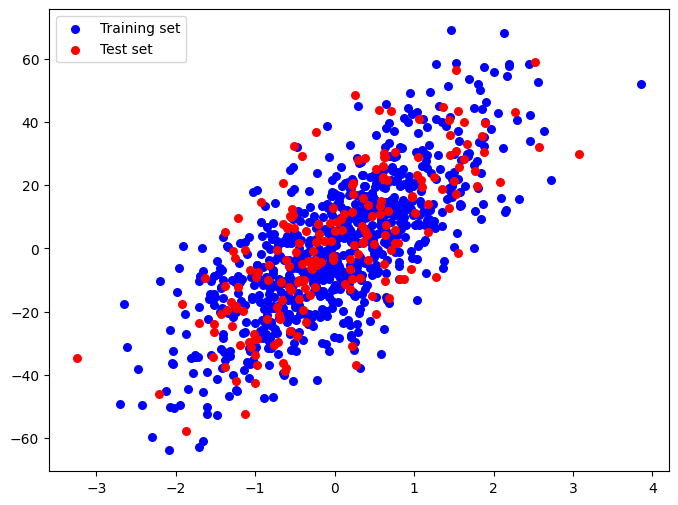

In [50]:
fig = plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], y_train, color='b', marker='o', s=30, label="Training set")
plt.scatter(X_test[:,0], y_test, color='r', marker='o', s=30, label="Test set")
plt.legend()
plt.show()

## Comparison with `sklearn` and `PyTorch` models

### Scratch Model

In [51]:
# Own model
scratch_model = LinearRegression(lr=0.01, n_iters=1000)

start = perf_counter()
scratch_model.fit(X_train_scaled, y_train)
scratch_fit_time = perf_counter() - start

start = perf_counter()
scratch_preds = scratch_model.predict(X_test_scaled)
scratch_predict_time = perf_counter() - start

### `Sklearn` Model
While the model from scratch and the `pytorch` implementation use gradient descent, the `sklearn` implementation of the Linear Regression solves the least-squares problem directly, so there is no epoch-by-epoch loss history, and the fit part should be much faster.

In [52]:
# Sklearn model
sklearn_model = SklearnLinearRegression()

start = perf_counter()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_model.predict(X_test_scaled)
sklearn_predict_time = perf_counter() - start

### `PyTorch` Model

In [53]:
# Pytorch model training
torch.manual_seed(42)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

torch_model = nn.Linear(X_train_scaled.shape[1], 1)
# initialize weights and biases to 0 for fair comparison with scratch model
with torch.no_grad():
    torch_model.weight.zero_()
    torch_model.bias.zero_()

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.01)

torch_loss_history = []

start = perf_counter()

for _ in range(1000):
    y_pred = torch_model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)

    torch_loss_history.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

torch_fit_time = perf_counter() - start

# Torch model prediction
start = perf_counter()

with torch.no_grad():
    torch_preds = torch_model(X_test_tensor).numpy().ravel()

torch_predict_time = perf_counter() - start

### Results
From the results, it looks like the metrics are almost the same for all the models. The only metric to change is the fit and predict time, where the `sklearn` model is the fastest in fitting and the scratch model is the fastest in predicting. The `pytorch` model is the slowest in predicting by far.

This can be explained with the fact that this is a small linear regression problem, where `PyTorch`'s advantages, such as GPU acceleration and batching, are swallowed by the overhead.

In [54]:
results = {
    "From scratch": {
        "MSE": mean_squared_error(y_test, scratch_preds),
        "RMSE": root_mean_squared_error(y_test, scratch_preds),
        "MAE": mean_absolute_error(y_test, scratch_preds),
        "R2": r2_score(y_test, scratch_preds),
        "Fit time": scratch_fit_time,
        "Predict time": scratch_predict_time,
    },
    "Scikit-learn": {
        "MSE": mean_squared_error(y_test, sklearn_preds),
        "RMSE": root_mean_squared_error(y_test, sklearn_preds),
        "MAE": mean_absolute_error(y_test, sklearn_preds),
        "R2": r2_score(y_test, sklearn_preds),
        "Fit time": sklearn_fit_time,
        "Predict time": sklearn_predict_time,
    },
    "PyTorch": {
        "MSE": mean_squared_error(y_test, torch_preds),
        "RMSE": root_mean_squared_error(y_test, torch_preds),
        "MAE": mean_absolute_error(y_test, torch_preds),
        "R2": r2_score(y_test, torch_preds),
        "Fit time": torch_fit_time,
        "Predict time": torch_predict_time,
    }
}

results_df = pd.DataFrame(results).T
results_df

,MSE,RMSE,MAE,R2,Fit time,Predict time
From scratch,242.774817,15.581233,12.257272,0.524609,0.067942,0.000117
Scikit-learn,242.774817,15.581233,12.257272,0.524609,0.001860,0.000218
PyTorch,242.774761,15.581231,12.257272,0.524609,0.340879,0.000175


## Plots and Metrics

### Loss Curves plots
If the difference curve stays close to zero, both implementations are converging almost identically.
If it drifts sistematically, something differs: initialization, update rule, precision, or optimizer behavior.

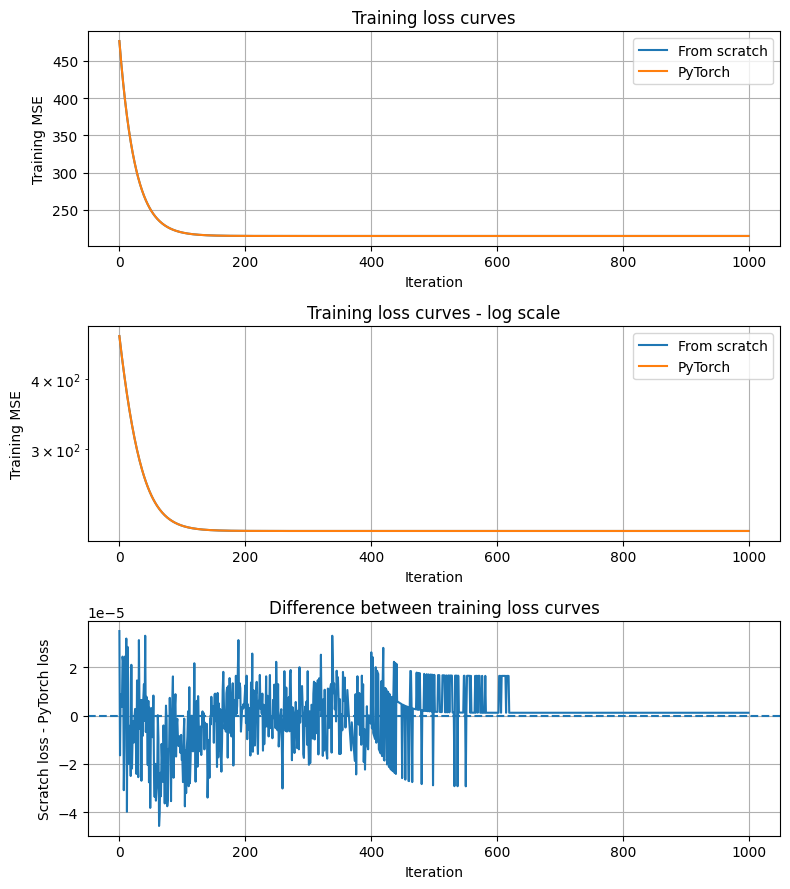

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9))

loss_diff = np.array(scratch_model.loss_history) - np.array(torch_loss_history)

axes[0].plot(scratch_model.loss_history, label="From scratch")
axes[0].plot(torch_loss_history, label="PyTorch")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Training MSE")
axes[0].set_title("Training loss curves")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(scratch_model.loss_history, label="From scratch")
axes[1].plot(torch_loss_history, label="PyTorch")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Training MSE")
axes[1].set_title("Training loss curves - log scale")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(loss_diff)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Scratch loss - PyTorch loss")
axes[2].set_title("Difference between training loss curves")
axes[2].axhline(0, linestyle="--")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Parity Plot
Here the predicted values are plotted against their true values. The diagonal is the perfect prediction.

If the points are close to the diagonal, the predictions are good.

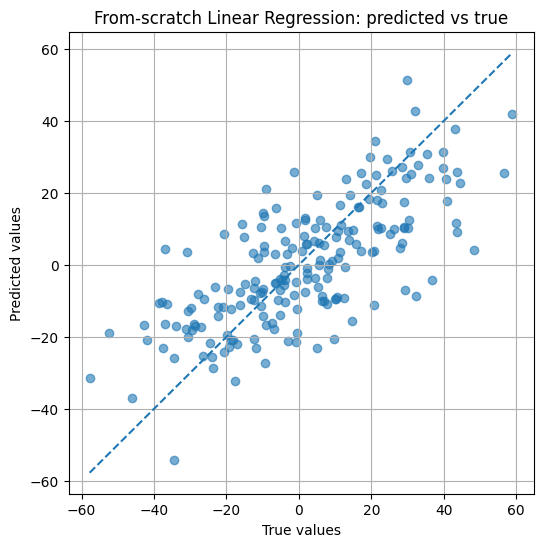

In [56]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, scratch_preds, alpha=0.6)

min_value = min(y_test.min(), scratch_preds.min())
max_value = max(y_test.max(), scratch_preds.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("From-scratch Linear Regression: predicted vs true")
plt.grid(True)

plt.show()

### Residual Plot
Here I plot the residuals, that is the difference between each `y_test` value and its prediction. The predictions are good if the distributions of the residuals is centered around zero.

A curved structure points to the fact that the model is missing nonlinearity, while a funnel shape signals that the error variance changes with prediction size. Both of these things are issues.

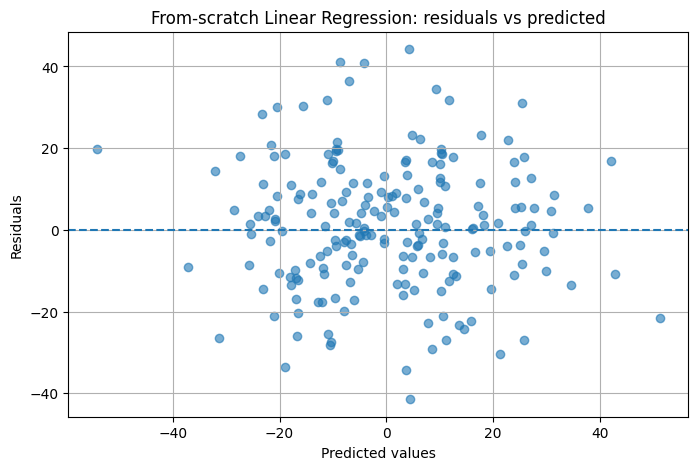

In [57]:
scratch_residuals = y_test - scratch_preds

plt.figure(figsize=(8, 5))

plt.scatter(scratch_preds, scratch_residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("From-scratch Linear Regression: residuals vs predicted")
plt.grid(True)

plt.show()

### Fit Plot

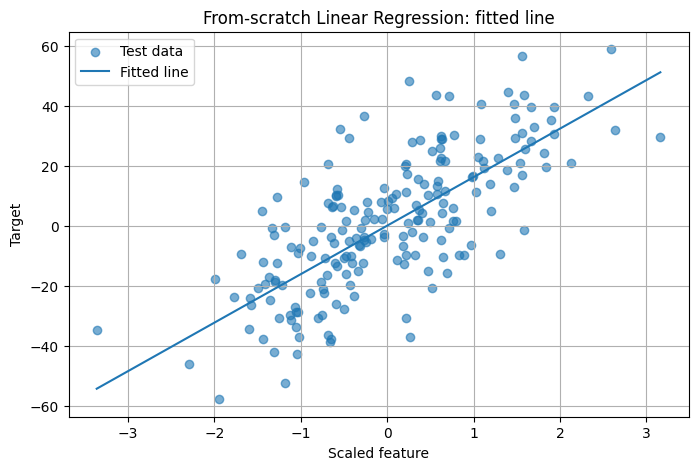

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.6, label="Test data")

x_line = np.linspace(
    X_test_scaled[:, 0].min(),
    X_test_scaled[:, 0].max(),
    100
)

y_line = scratch_model.weights[0] * x_line + scratch_model.bias

plt.plot(x_line, y_line, label="Fitted line")

plt.xlabel("Scaled feature")
plt.ylabel("Target")
plt.title("From-scratch Linear Regression: fitted line")
plt.legend()
plt.grid(True)

plt.show()

## Hyperparameter Sweeps
I will now test different values of the hyperparameters in order to find the ones that maximize efficiency.

### Learning Rate
The expected behavior is:
- `lr` too small -> slow convergence
- `lr` reasonable -> smooth convergence
- `lr` too large -> unstable or diverges

Since the dataset that was chosen for this test is very simple (linear, with a single feature, and moderate noise), gradient descent keeps working also at very high `lr`. However, at `lr=1` the loss never changes, while at `lr=1.1` it diverges, and raising `lr` eventually brings to numerical overflow, and all the metrics turn out to be `NaN`.

A noticeable phenomenon is that, for example, the loss curve and the metrics for `lr=0.999` are equal to those for `lr=0.001`, and in general the same is true for all values `lr` and `1-lr`. This is due to the nature of the dataset. In fact, since we have only one feature and it is standardized, meaning that the $\mu_X=0$ and $\sigma_X^2=1$, and furthermore the dataset was generated without an explicit intercept term, so the optimal fitted bias is expected to be very close to zero, the derivative of the loss function $J$ with respect to the weights $w$ is approximately
$$
\frac{\partial J}{\partial w}=dw\approx 2\cdot (w-w_{opt})
$$
With $w_{opt}$ optimal weight.
This means that when I apply gradient descent, and move by 
$$
-\alpha\nabla J(w)=-2\alpha (w-w_{opt}) \quad\rightarrow\quad w_{t+1}=w_t-2\alpha (w_t-w_{opt})
$$ 
along the loss curve, the update factor for the distance from the optimum becomes
$$
w_{t+1} - w_{opt} = (1 - 2\alpha)(w_t - w_{opt}) = (1 - 2\alpha)^{t+1}(w_0-w_{opt})
$$
Therefore
- if |1 - 2α| < 1, convergence occurs
- if |1 - 2α| = 1, oscillation occurs
- if |1 - 2α| > 1, divergence occurs

In [ ]:
values = list(np.logspace(-8,0,100))
sweep_results, loss_curves = parameter_sweep_regression(
    model_cls=LinearRegression, 
    param_grid={
        'lr': values
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000})

In [104]:
sweep_df = pd.DataFrame(sweep_results)
sweep_df

,lr,n_iters,final_train_loss,test_mse,test_rmse,test_mae,test_r2,fit_time,initial_train_loss,min_train_loss,stable,converged
0,1.000000e-08,1000,476.663317,512.769252,22.644409,18.272483,-0.004082,0.028793,476.673772,476.663317,True,True
1,1.204504e-08,1000,476.661180,512.766963,22.644358,18.272441,-0.004077,0.028178,476.673772,476.661180,True,True
2,1.450829e-08,1000,476.658605,512.764207,22.644297,18.272392,-0.004072,0.032105,476.673772,476.658605,True,True
3,1.747528e-08,1000,476.655503,512.760887,22.644224,18.272332,-0.004065,0.026720,476.673772,476.655503,True,True
4,2.104904e-08,1000,476.651767,512.756888,22.644136,18.272261,-0.004057,0.025414,476.673772,476.651767,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,4.750810e-01,1000,215.052827,242.774817,15.581233,12.257272,0.524609,0.023245,476.673772,215.052827,True,True
96,5.722368e-01,1000,215.052827,242.774817,15.581233,12.257272,0.524609,0.023182,476.673772,215.052827,True,True
97,6.892612e-01,1000,215.052827,242.774817,15.581233,12.257272,0.524609,0.022910,476.673772,215.052827,True,True
98,8.302176e-01,1000,215.052827,242.774817,15.581233,12.257272,0.524609,0.021713,476.673772,215.052827,True,True


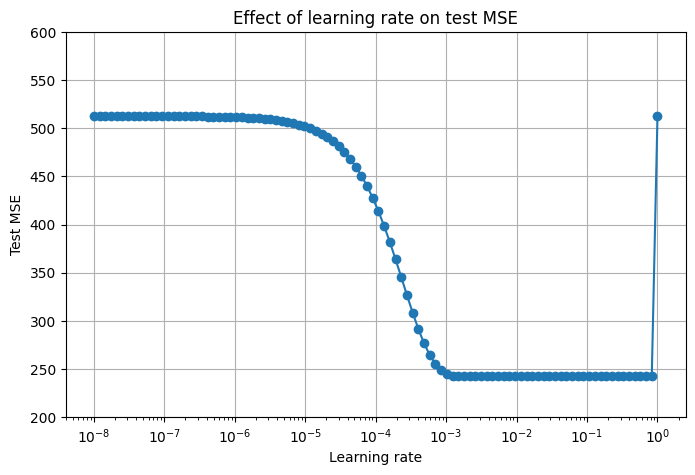

In [105]:
stable_df = sweep_df[sweep_df["stable"]]

plt.figure(figsize=(8, 5))
plt.plot(stable_df["lr"], stable_df["test_mse"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Test MSE")
plt.title("Effect of learning rate on test MSE")
plt.ylim(2e2,6e2)
plt.grid(True)
plt.show()

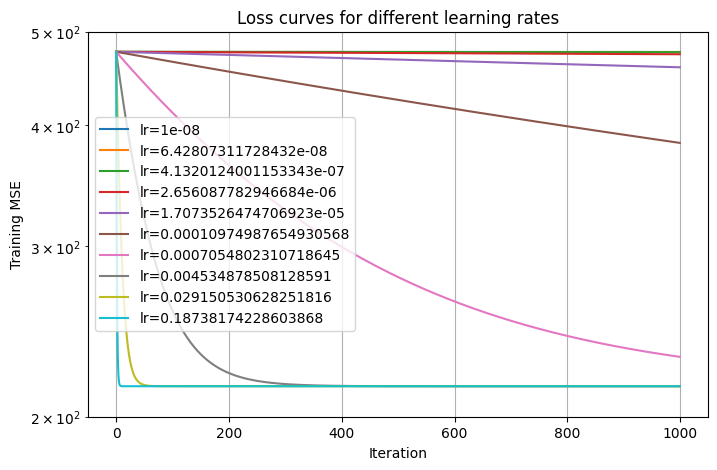

In [106]:
plt.figure(figsize=(8, 5))

max_loss_to_plot = 1e10

for item in loss_curves[::10]:

    loss_array = item['loss']

    # plot only valid values of loss
    valid_mask = (
        np.isfinite(loss_array)
        & (loss_array > 0)
        & (loss_array < max_loss_to_plot)
    )

    if valid_mask.sum() == 0:
        continue

    plt.plot(
        np.arange(len(loss_array))[valid_mask],
        loss_array[valid_mask],
        label=f"lr={item['lr']}"
    )

plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Loss curves for different learning rates")
plt.ylim(2e2,5e2)
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

## Benchmark Timings
In this section I will get a much more accurate measurement for the time spent for the fitting for each model by averaging the time over several runs.

In [63]:
scratch_timing = benchmark_model(
    lambda: LinearRegression(lr=0.01, n_iters=1000),
    X_train_scaled,
    y_train,
    X_test_scaled,
)

sklearn_timing = benchmark_model(
    lambda: SklearnLinearRegression(),
    X_train_scaled,
    y_train,
    X_test_scaled,
)

pytorch_timing = benchmark_pytorch_model(
    model_factory = lambda: nn.Linear(X_train_scaled.shape[1], 1), 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled,
    n_iters=1000,
    lr=0.01, 
    n_runs=30, 
    criterion_cls = nn.MSELoss,
    optimizer_cls = torch.optim.SGD
)

In [64]:
timing_df = pd.DataFrame({
    "From scratch": scratch_timing,
    "Scikit-learn": sklearn_timing,
    "PyTorch": pytorch_timing
}).T

timing_df

,fit_time_mean,fit_time_std,predict_time_mean,predict_time_std
From scratch,0.031091,0.001762,0.000009,0.000005
Scikit-learn,0.000617,0.000072,0.000102,0.000013
PyTorch,0.450135,0.058597,0.000082,0.000039


## Harder Dataset
In this section, I try to use a more complex dataset, in order to check the performance of the model, and verify that the phenomenon encountered before with the learning rate does not appear anymore as the dimensionality of the dataset increases above 1.

In the 1-feature standardized case, the critical learning rate was around 1.0.

In the 20-feature case, the stability threshold is lower ($\sim0.88$) because convergence is controlled by the largest eigenvalue of the feature covariance matrix (which in 1D was simply $w_{opt}$).

The more elongated / ill-conditioned the loss surface is, the smaller the safe learning rate must be.

In [107]:
X, y = make_regression(
    n_samples=5000,
    n_features=20,
    noise=50,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
values = list(np.logspace(-8,-1,100))
sweep_results, loss_curves = parameter_sweep_regression(
    model_cls=LinearRegression, 
    param_grid={
        'lr': values
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000})
sweep_df = pd.DataFrame(sweep_results)
sweep_df

,lr,n_iters,final_train_loss,test_mse,test_rmse,test_mae,test_r2,fit_time,initial_train_loss,min_train_loss,stable,converged
0,1.000000e-08,1000,27969.073571,27814.733210,166.777496,135.340079,-0.000805,0.092892,27970.104448,27969.073571,True,True
1,1.176812e-08,1000,27968.891304,27814.552499,166.776954,135.339634,-0.000798,0.080764,27970.104448,27968.891304,True,True
2,1.384886e-08,1000,27968.676812,27814.339838,166.776317,135.339110,-0.000791,0.096598,27970.104448,27968.676812,True,True
3,1.629751e-08,1000,27968.424397,27814.089578,166.775566,135.338493,-0.000782,0.082172,27970.104448,27968.424397,True,True
4,1.917910e-08,1000,27968.127355,27813.795072,166.774684,135.337768,-0.000771,0.081189,27970.104448,27968.127355,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,5.214008e-02,1000,2465.235960,2618.104484,51.167416,40.969224,0.905798,0.096816,27970.104448,2465.235960,True,True
96,6.135907e-02,1000,2465.235960,2618.104484,51.167416,40.969224,0.905798,0.150619,27970.104448,2465.235960,True,True
97,7.220809e-02,1000,2465.235960,2618.104484,51.167416,40.969224,0.905798,0.109922,27970.104448,2465.235960,True,True
98,8.497534e-02,1000,2465.235960,2618.104484,51.167416,40.969224,0.905798,0.140423,27970.104448,2465.235960,True,True


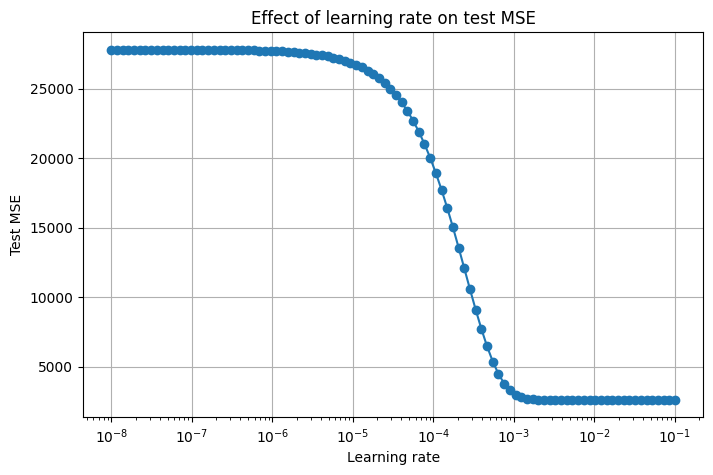

In [134]:
stable_df = sweep_df[sweep_df["stable"]]

plt.figure(figsize=(8, 5))
plt.plot(stable_df["lr"], stable_df["test_mse"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Test MSE")
plt.title("Effect of learning rate on test MSE")
#plt.ylim(2e2,6e2)
plt.grid(True)
plt.show()